## Q Learning

### 1. Imports

In [ ]:
import os
import random
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve)

### 2. Random Seed

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

### 3. Load Dataset

In [ ]:
RL_ENVIRONMENT_PATH = "rl_environment.pkl"

with open(RL_ENVIRONMENT_PATH, "rb") as f:
    folds = pickle.load(f)

print("Number of folds :", len(folds))

Number of folds : 5


### 4. Hyperparameters

In [ ]:
# Number of training episodes
NUM_EPISODES = 500

# Maximum number of actions per episode
MAX_STEPS = 20

# Discount factor
GAMMA = 0.99

# Learning rate
ALPHA = 0.25

# Exploration parameters
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.999

### 5. RL Environment

In [ ]:
class DiseasePredictionEnvironment:

    def __init__(self, states, labels):

        self.states = states
        self.labels = labels

        self.num_samples = len(states)

        # Two actions only
        self.action_size = 2

        self.reset()

    def reset(self):

        self.index = 0

        return self.states[self.index]

    def step(self, action):

        true_label = self.labels[self.index]

        reward = 1 if action == true_label else -1

        self.index += 1

        done = self.index >= self.num_samples

        if done:

            next_state = np.zeros_like(self.states[0])

        else:

            next_state = self.states[self.index]

        return next_state, reward, done

### 6. Verify the Environment

In [ ]:
fold = folds[0]

train_states = fold["states_train"]
train_labels = fold["labels_train"]

env = DiseasePredictionEnvironment(
    train_states,
    train_labels
)

state = env.reset()

print("State size :", len(state))
print("Action size:", env.action_size)

State size : 15
Action size: 2


### 7. Test One Random Action

In [ ]:
state = env.reset()

action = np.random.randint(2)

next_state, reward, done = env.step(action)


print("Reward :", reward)
print("Done   :", done)
print("State shape :", next_state.shape)

Reward : -1
Done   : False
State shape : (15,)


### 8. State Discretization

In [ ]:
# ==========================================================
# State Discretization
# ==========================================================

NUM_BINS = 3

def discretize_state(state, num_bins=NUM_BINS):
    """
    Convert a continuous state into a discrete tuple.
    """

    state = np.asarray(state)

    state = np.clip(state, 0.0, 1.0)

    discrete_state = tuple(
        np.minimum(
            (state * num_bins).astype(int),
            num_bins - 1
        )
    )

    return discrete_state

### 9. Q-Learning Agent

In [ ]:
# ==========================================================
# Classical Q-Learning Agent
# ==========================================================

class QLearningAgent:

    def __init__(self,
                 action_size,
                 alpha=0.25,
                 gamma=0.99,
                 epsilon=1.0,
                 epsilon_min=0.05,
                 epsilon_decay=0.999):

        self.action_size = action_size

        self.alpha = alpha
        self.gamma = gamma

        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Q-table
        self.q_table = {}

    ######################################################

    def initialize_state(self, state):

        if state not in self.q_table:

            self.q_table[state] = np.zeros(self.action_size)

    ######################################################

    def choose_action(self, state):

        self.initialize_state(state)

        if np.random.rand() < self.epsilon:

            return np.random.randint(self.action_size)

        return np.argmax(self.q_table[state])

    ######################################################

    def update(self,
               state,
               action,
               reward,
               next_state,
               done):

        self.initialize_state(state)
        self.initialize_state(next_state)

        current_q = self.q_table[state][action]

        if done:

            target = reward

        else:

            target = reward + self.gamma * np.max(
                self.q_table[next_state]
            )

        self.q_table[state][action] += self.alpha * (
            target - current_q
        )

    ######################################################

    def decay_epsilon(self):

        if self.epsilon > self.epsilon_min:

            self.epsilon *= self.epsilon_decay

            self.epsilon = max(
                self.epsilon,
                self.epsilon_min
            )

### 10. Initialize the Agent

In [ ]:
# ==========================================================
# Create Agent
# ==========================================================

agent = QLearningAgent(
    action_size=env.action_size,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY
)

print("Q-Learning Agent Created")
print("Number of Actions :", agent.action_size)

Q-Learning Agent Created
Number of Actions : 2


### 11. Verify Agent

In [ ]:
# ==========================================================
# Test Agent
# ==========================================================

state = env.reset()

state = discretize_state(state)

action = agent.choose_action(state)

next_state, reward, done = env.step(action)

next_state = discretize_state(next_state)

agent.update(
    state,
    action,
    reward,
    next_state,
    done
)

print("State      :", state)
print("Action     :", action)
print("Reward     :", reward)
print("Done       :", done)
print("Q-table Size:", len(agent.q_table))

State      : (np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(2))
Action     : 0
Reward     : -1
Done       : False
Q-table Size: 2


### 12. Training Function

In [ ]:
# ==========================================================
# Q-Learning Training Function
# ==========================================================

def train_q_learning(env, agent, num_episodes):

    rewards_history = []
    steps_history = []

    for episode in tqdm(range(num_episodes), desc="Training"):

        state = discretize_state(env.reset())

        total_reward = 0
        step_count = 0

        while True:

            action = agent.choose_action(state)

            next_state, reward, done = env.step(action)

            next_state = discretize_state(next_state)

            agent.update(
                state,
                action,
                reward,
                next_state,
                done
            )

            state = next_state

            total_reward += reward
            step_count += 1

            if done:
                break

        agent.decay_epsilon()

        rewards_history.append(total_reward)
        steps_history.append(step_count)

    return rewards_history, steps_history

### 13. Train Across All Folds

In [ ]:
# ==========================================================
# Train Using 5-Fold Cross Validation
# ==========================================================

all_agents = []
all_reward_histories = []
all_step_histories = []

for fold_number, fold in enumerate(folds):

    print("=" * 60)
    print(f"Training Fold {fold_number + 1}/{len(folds)}")
    print("=" * 60)

    train_states = fold["states_train"]
    train_labels = fold["labels_train"]

    env = DiseasePredictionEnvironment(
        train_states,
        train_labels
    )

    agent = QLearningAgent(
        action_size=env.action_size,
        alpha=ALPHA,
        gamma=GAMMA,
        epsilon=EPSILON,
        epsilon_min=EPSILON_MIN,
        epsilon_decay=EPSILON_DECAY
    )

    rewards, steps = train_q_learning(
        env,
        agent,
        NUM_EPISODES
    )

    all_agents.append(agent)
    all_reward_histories.append(rewards)
    all_step_histories.append(steps)

print("\nTraining Finished Successfully.")

Training Fold 1/5


Training: 100%|██████████| 500/500 [00:05<00:00, 91.51it/s]


Training Fold 2/5


Training: 100%|██████████| 500/500 [00:05<00:00, 84.84it/s]


Training Fold 3/5


...

Training Fold 4/5


Training: 100%|██████████| 500/500 [00:05<00:00, 91.93it/s]


Training Fold 5/5


Training: 100%|██████████| 500/500 [00:05<00:00, 89.23it/s]


Training Finished Successfully.


### 14. Plot Reward Curve

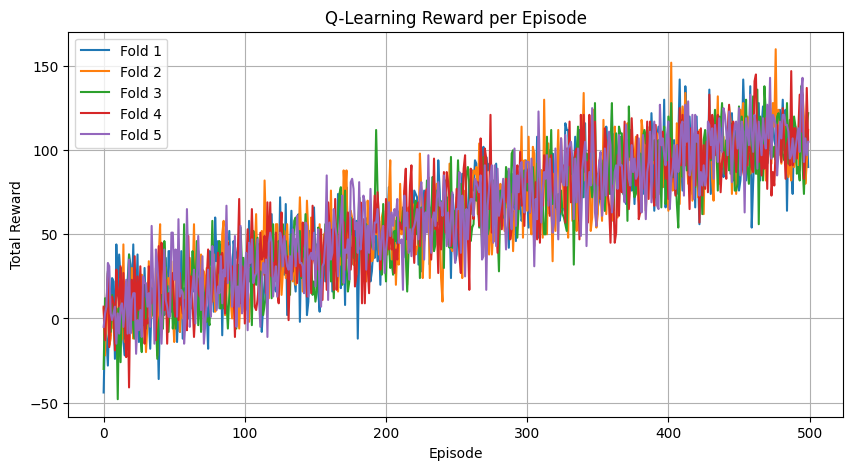

In [ ]:
# ==========================================================
# Reward Curve
# ==========================================================

plt.figure(figsize=(10,5))

for i, rewards in enumerate(all_reward_histories):

    plt.plot(
        rewards,
        label=f"Fold {i+1}"
    )

plt.title("Q-Learning Reward per Episode")

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.grid(True)

plt.legend()

plt.show()

### 15. Average Reward Curve

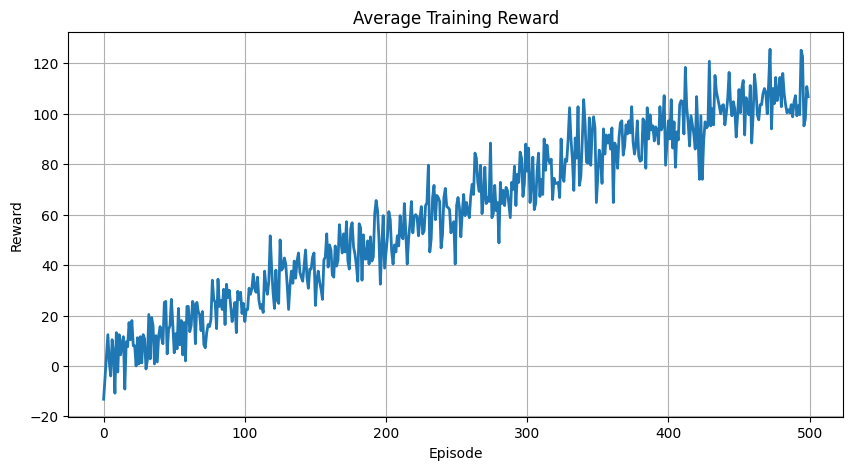

In [ ]:
# ==========================================================
# Average Reward
# ==========================================================

reward_matrix = np.array(all_reward_histories)

average_reward = reward_matrix.mean(axis=0)

plt.figure(figsize=(10,5))

plt.plot(
    average_reward,
    linewidth=2
)

plt.title("Average Training Reward")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

### 16. Average Episode Length

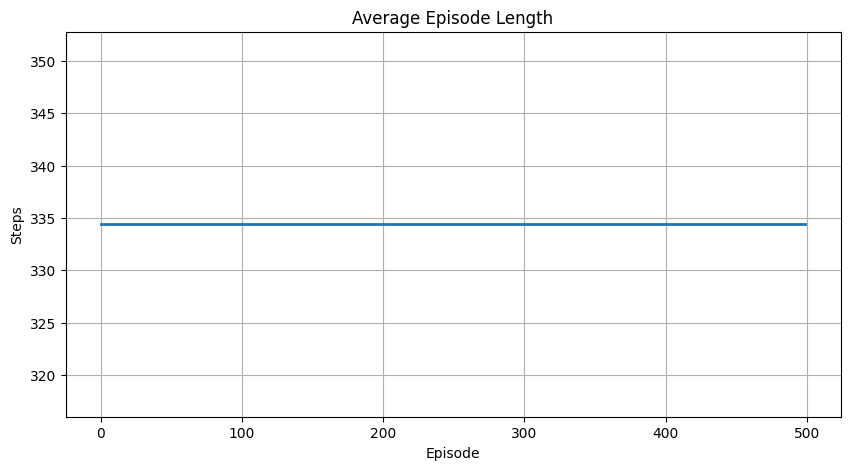

In [ ]:
# ==========================================================
# Episode Length
# ==========================================================

step_matrix = np.array(all_step_histories)

average_steps = step_matrix.mean(axis=0)

plt.figure(figsize=(10,5))

plt.plot(
    average_steps,
    linewidth=2
)

plt.title("Average Episode Length")

plt.xlabel("Episode")

plt.ylabel("Steps")

plt.grid(True)

plt.show()

### 17.  Evaluate One Fold

In [ ]:
# ==========================================================
# Evaluate a Trained Agent
# ==========================================================

def evaluate_agent(agent,
                   test_states,
                   test_labels):

    y_true = []
    y_pred = []
    y_score = []

    for state,label in zip(test_states,test_labels):

        state = discretize_state(state)

        if state in agent.q_table:

            q_values = agent.q_table[state]

        else:

            # Unknown state

            q_values = np.array([0.5,0.5])

        prediction = np.argmax(q_values)

        exp_q = np.exp(q_values - np.max(q_values))
        probability = exp_q[1] / np.sum(exp_q)

        y_true.append(label)
        y_pred.append(prediction)
        y_score.append(probability)

    return np.array(y_true),np.array(y_pred),np.array(y_score)

### 18. Evaluate All Five Folds

In [ ]:
# ==========================================================
# Evaluate Every Fold
# ==========================================================

results = []

all_true = []
all_pred = []
all_score = []

for fold_number, fold in enumerate(folds):

    print(f"Evaluating Fold {fold_number+1}")

    test_states = fold["states_test"]
    test_labels = fold["labels_test"]

    agent = all_agents[fold_number]

    y_true, y_pred, y_score = evaluate_agent(
        agent,
        test_states,
        test_labels
    )

    all_true.extend(y_true)
    all_pred.extend(y_pred)
    all_score.extend(y_score)


    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    specificity = 0.0

    if (TN + FP) > 0:
        specificity = TN / (TN + FP)

    fold_result = {

        "Fold": fold_number + 1,

        "Accuracy":
            accuracy_score(y_true, y_pred),

        "Precision":
            precision_score(y_true, y_pred),

        "Recall":
            recall_score(y_true, y_pred),

        "F1":
            f1_score(y_true, y_pred),

        "Specificity":
            specificity,

        "ROC_AUC":
            roc_auc_score(y_true, y_score)
            if len(np.unique(y_true)) > 1
            else np.nan

    }

    results.append(fold_result)

Evaluating Fold 1
Evaluating Fold 2
Evaluating Fold 3
Evaluating Fold 4
Evaluating Fold 5


### 19. Create Results Table

In [ ]:
results_df = pd.DataFrame(results)

results_df

,Fold,Accuracy,Precision,Recall,F1,Specificity,ROC_AUC
0,1,0.619048,0.714286,0.365854,0.483871,0.860465,0.700794
1,2,0.607143,0.760000,0.413043,0.535211,0.842105,0.684783
2,3,0.595238,0.708333,0.386364,0.500000,0.825000,0.709375
3,4,0.578313,0.800000,0.340426,0.477612,0.888889,0.667258
4,5,0.590361,0.842105,0.340426,0.484848,0.916667,0.596927


### 20. Average Performance

In [ ]:
print("="*60)
print("Average Performance")
print("="*60)

print("Accuracy     :",results_df["Accuracy"].mean())
print("Precision    :",results_df["Precision"].mean())
print("Recall       :",results_df["Recall"].mean())
print("F1 Score     :",results_df["F1"].mean())
print("Specificity  :",results_df["Specificity"].mean())
print("ROC AUC      :",results_df["ROC_AUC"].mean())

Average Performance
Accuracy     : 0.5980206540447505
Precision    : 0.7649448621553885
Recall       : 0.3692223673981757
F1 Score     : 0.4963085320989123
Specificity  : 0.866625186998504
ROC AUC      : 0.6718272213646076


### 21. Save Results

In [ ]:
results_df.to_csv(
    "evaluation_results.csv",
    index=False
)

print("Saved evaluation_results.csv")

Saved evaluation_results.csv


### 22. Overall Confusion Matrix

In [ ]:
cm = confusion_matrix(all_true, all_pred)
print(cm)

[[167  26]
 [142  83]]


### 23. Plot Confusion Matrix

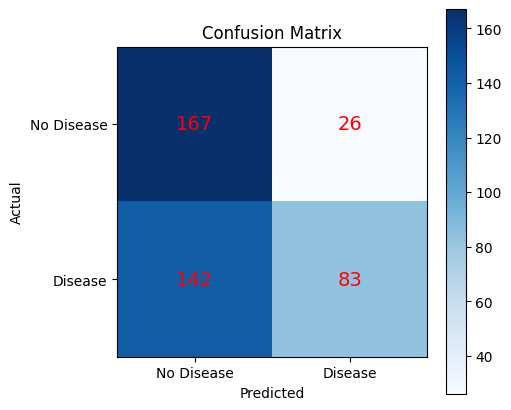

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(cm,cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["No Disease","Disease"])

plt.yticks([0,1],["No Disease","Disease"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,str(cm[i,j]),
                 ha="center",
                 va="center",
                 color="red",
                 fontsize=14)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### 24. ROC Curve

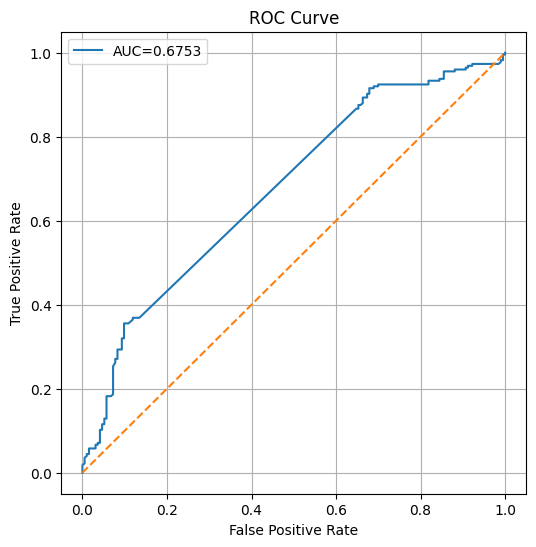

In [ ]:
fpr,tpr,_ = roc_curve(
    all_true,
    all_score
)

auc = roc_auc_score(
    all_true,
    all_score
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

### 25. Export Best-Performing Fold Model (Highest Accuracy)

In [ ]:
# ==========================================================
# Select and Export the Best-Performing Fold Model
#
# Q-Learning has no neural-network weights -- the trained artifact is the
# Q-table (a dict mapping discretized states to action-values). This cell
# compares the per-fold Accuracy already computed above, then saves ONLY
# the best fold's Q-table to a canonical best_model/ directory with a
# metadata.json, matching the artifact contract in models/README.md.
# ==========================================================
import os
import pickle
import json
from datetime import datetime, timezone

BEST_MODEL_DIR = "best_model"
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

if "results_df" not in globals():
    raise RuntimeError("results_df not found. Run the evaluation cells above first.")

best_row = results_df.loc[results_df["Accuracy"].idxmax()]
best_fold = int(best_row["Fold"])
best_accuracy = float(best_row["Accuracy"])

print("=" * 70)
print("BEST FOLD SELECTION")
print("=" * 70)
print(results_df[["Fold", "Accuracy", "ROC_AUC"]].to_string(index=False))
print()
print(f"Best Fold      : {best_fold}")
print(f"Best Accuracy  : {best_accuracy:.4f}")

best_agent = all_agents[best_fold - 1]

best_model_path = os.path.join(BEST_MODEL_DIR, "model.pkl")
with open(best_model_path, "wb") as f:
    pickle.dump({
        "q_table": best_agent.q_table,
        "action_size": best_agent.action_size,
        "num_bins": NUM_BINS
    }, f)

print(f"\nBest Q-table saved to: {best_model_path}")

# Canonical feature order (see backend/utils/featureContract.js).
CANONICAL_FEATURE_ORDER = [
    "thalach", "restecg", "oldpeak", "slope", "age",
    "sex", "cp", "exang", "trestbps", "fbs"
]

trained_state_dimension = len(folds[0]["states_train"][0])

metadata = {
    "model_version": f"qlearning-fold{best_fold}-{datetime.now(timezone.utc).strftime('%Y-%m-%d')}",
    "algorithm": "Q-Learning",
    "feature_order": CANONICAL_FEATURE_ORDER,
    "preprocessing": {
        "note": (
            "States are discretized into NUM_BINS bins per feature via "
            "discretize_state() before Q-table lookup; any inference runtime "
            "must apply the identical discretization. Verify whether the "
            f"trained {trained_state_dimension}-dimension state matches the 10 "
            "raw canonical features above before deployment (see "
            "models/README.md, 'Known gap')."
        ),
        "num_bins": NUM_BINS,
        "trained_state_dimension": trained_state_dimension
    },
    "training_metadata": {
        "fold": best_fold,
        "num_folds": len(folds),
        "episodes": NUM_EPISODES,
        "trained_on": datetime.now(timezone.utc).strftime("%Y-%m-%d")
    },
    "evaluation_metadata": {
        "accuracy": float(best_row["Accuracy"]),
        "precision": float(best_row["Precision"]),
        "recall": float(best_row["Recall"]),
        "f1": float(best_row["F1"]),
        "roc_auc": None if pd.isna(best_row["ROC_AUC"]) else float(best_row["ROC_AUC"])
    },
    "runtime_compatibility": {
        "framework": "numpy",
        "min_python": "3.10"
    }
}

metadata_path = os.path.join(BEST_MODEL_DIR, "metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved to: {metadata_path}")

try:
    from google.colab import files
    files.download(best_model_path)
    files.download(metadata_path)
    print("\nDownload triggered for best_model/model.pkl and metadata.json")
except ImportError:
    print("\nNot running in Google Colab -- files are available locally at:")
    print(f"  {best_model_path}")
    print(f"  {metadata_path}")
print("=" * 70)

### 26. Export to JSON (Node-Loadable Format for the Backend)

In [ ]:
# ==========================================================
# Export the Best-Performing Fold's Q-Table to JSON
#
# The backend (Node.js) cannot unpickle a Python .pkl file. Since a Q-table
# is just a dict (no neural network), plain JSON is sufficient -- no ML
# runtime is needed on the backend side. This exports the SAME Q-table
# already saved to model.pkl, in addition to (not instead of) that file.
#
# Q-table keys are Python tuples in memory; JSON has no tuple type, so keys
# are serialized as JSON array strings (e.g. "[0,1,2,...]") -- this exact
# format must match backend/services/adapters/qtableAdapter.js's
# discretizeState() output.
# ==========================================================
import json

json_path = os.path.join(BEST_MODEL_DIR, "model.json")

serializable_q_table = {
    json.dumps(list(int(v) for v in state_key)): list(float(v) for v in action_values)
    for state_key, action_values in best_agent.q_table.items()
}

with open(json_path, "w") as f:
    json.dump({
        "action_size": best_agent.action_size,
        "num_bins": NUM_BINS,
        "q_table": serializable_q_table,
    }, f, indent=2)

print(f"Q-table exported as JSON to: {json_path}")
print(f"Number of discretized states in table: {len(serializable_q_table)}")

metadata["runtime_compatibility"]["export_format"] = "json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Updated metadata.json with export_format.")

try:
    from google.colab import files
    files.download(json_path)
    files.download(metadata_path)
    print("\nDownload triggered for best_model/model.json and updated metadata.json")
except ImportError:
    print(f"\nNot running in Google Colab -- file available locally at: {json_path}")